# 06 - Baseline Report Figures

This notebook regenerates the baseline figure set from the saved CSV outputs.
The figures are saved under `baseline/figures/report_ready`.


## Load plotting data


In [1]:
from pathlib import Path
import os, sys, time

def find_baseline_root():
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "baseline", base / "MuJoCo_RL_Project_Final_Submission" / "baseline"]:
            if (candidate / "baseline_summary.md").exists() and (candidate / "results").exists():
                return candidate.resolve()
    raise RuntimeError("Could not locate baseline folder")

BASE_DIR = find_baseline_root()
os.chdir(BASE_DIR)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RAW_DIR = BASE_DIR / "results" / "raw"
PROC_DIR = BASE_DIR / "results" / "processed"
FINAL_DIR = BASE_DIR / "results" / "final"
FIG_DIR = BASE_DIR / "figures"
REPORT_FIG_DIR = FIG_DIR / "report_ready"
for folder in [RAW_DIR, PROC_DIR, FINAL_DIR, REPORT_FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ENV_IDS = ["HalfCheetah-v5", "Hopper-v5", "Walker2d-v5"]
ALGORITHMS = ["PPO", "SAC", "TD3", "DDPG", "TQC"]
print(f"Baseline root: {BASE_DIR}")
print(f"Python: {sys.executable}")


Baseline root: D:\MuJoCo_RL_Project\MuJoCo_RL_Project_Final_Submission\baseline
Python: C:\Users\digilians01\.conda\envs\RL_PROJECT\python.exe


In [2]:
import seaborn as sns
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "font.size": 10})
COLORS = {"PPO": "#2196F3", "SAC": "#4CAF50", "TD3": "#FF9800", "DDPG": "#F44336", "TQC": "#9C27B0"}
eval_frames = [pd.read_csv(RAW_DIR / f"{env}_eval_log.csv") for env in ENV_IDS if (RAW_DIR / f"{env}_eval_log.csv").exists()]
eval_log = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
final_eval = pd.read_csv(PROC_DIR / "final_eval_all.csv") if (PROC_DIR / "final_eval_all.csv").exists() else pd.DataFrame()
robust_eval = pd.read_csv(PROC_DIR / "robustness_eval_all.csv") if (PROC_DIR / "robustness_eval_all.csv").exists() else pd.DataFrame()
perf_df = pd.read_csv(FINAL_DIR / "table_final_returns.csv") if (FINAL_DIR / "table_final_returns.csv").exists() else pd.DataFrame()
print(len(eval_log), "learning-curve rows")
print(len(final_eval), "final-evaluation rows")
print(len(robust_eval), "robustness rows")


15300 learning-curve rows
85 final-evaluation rows
6800 robustness rows


## Save helper


In [3]:
SAVE_FIGURES = False

def save_fig(fig, name):
    if not SAVE_FIGURES:
        print(f"Generated {name}; existing figure files were left unchanged.")
        return
    REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(REPORT_FIG_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(REPORT_FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    print(f"Saved {name}.png and {name}.pdf")


## Learning curves


Generated fig_learning_curves_all; existing figure files were left unchanged.


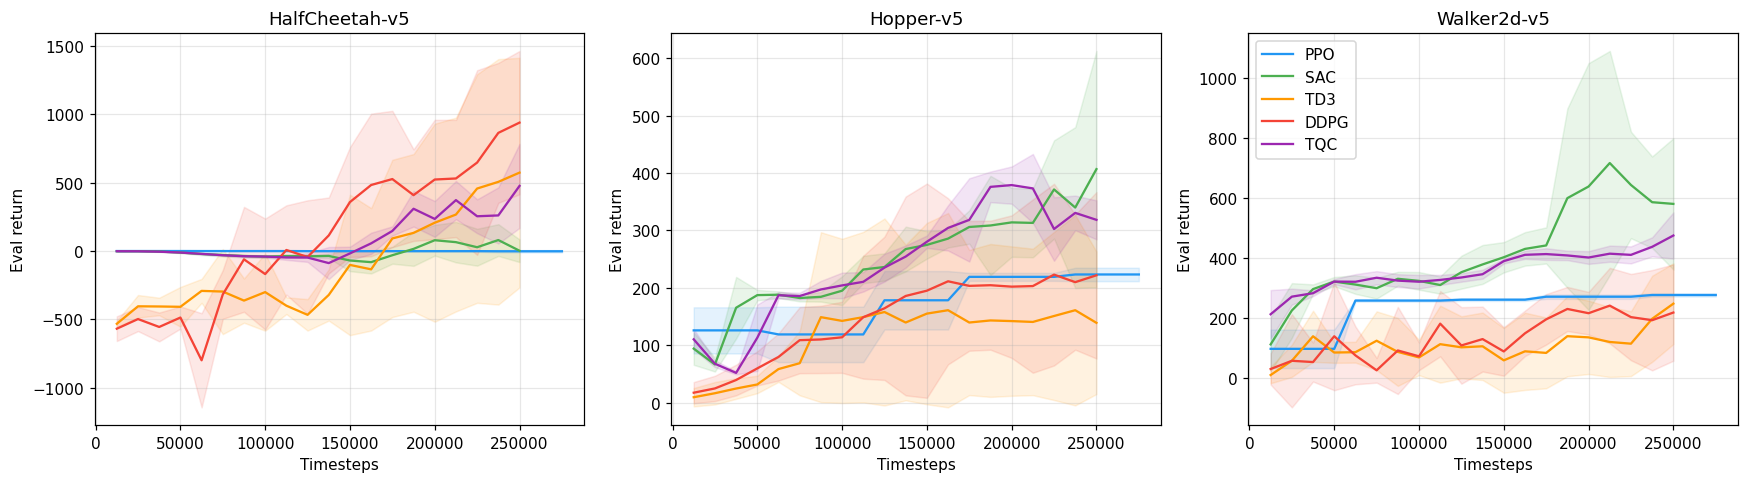

In [4]:
fig, axes = plt.subplots(1, len(ENV_IDS), figsize=(16, 4.5), squeeze=False)
for ax, env_id in zip(axes[0], ENV_IDS):
    env_data = eval_log[eval_log["environment"] == env_id]
    for algo in ALGORITHMS:
        part = env_data[env_data["algorithm"] == algo]
        if part.empty:
            continue
        curve = (part.groupby(["seed", "eval_timestep"])["eval_return"].mean().reset_index()
                 .groupby("eval_timestep")["eval_return"].agg(["mean", "std"]).reset_index())
        ax.plot(curve["eval_timestep"], curve["mean"], color=COLORS[algo], label=algo)
        ax.fill_between(curve["eval_timestep"], curve["mean"] - curve["std"],
                        curve["mean"] + curve["std"], color=COLORS[algo], alpha=0.12)
    ax.set_title(env_id)
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Eval return")
    ax.grid(alpha=0.3)
axes[0, -1].legend(ncol=1)
plt.tight_layout()
save_fig(fig, "fig_learning_curves_all")
plt.show()


## Final performance and variability


Generated fig_baseline_performance_variability; existing figure files were left unchanged.


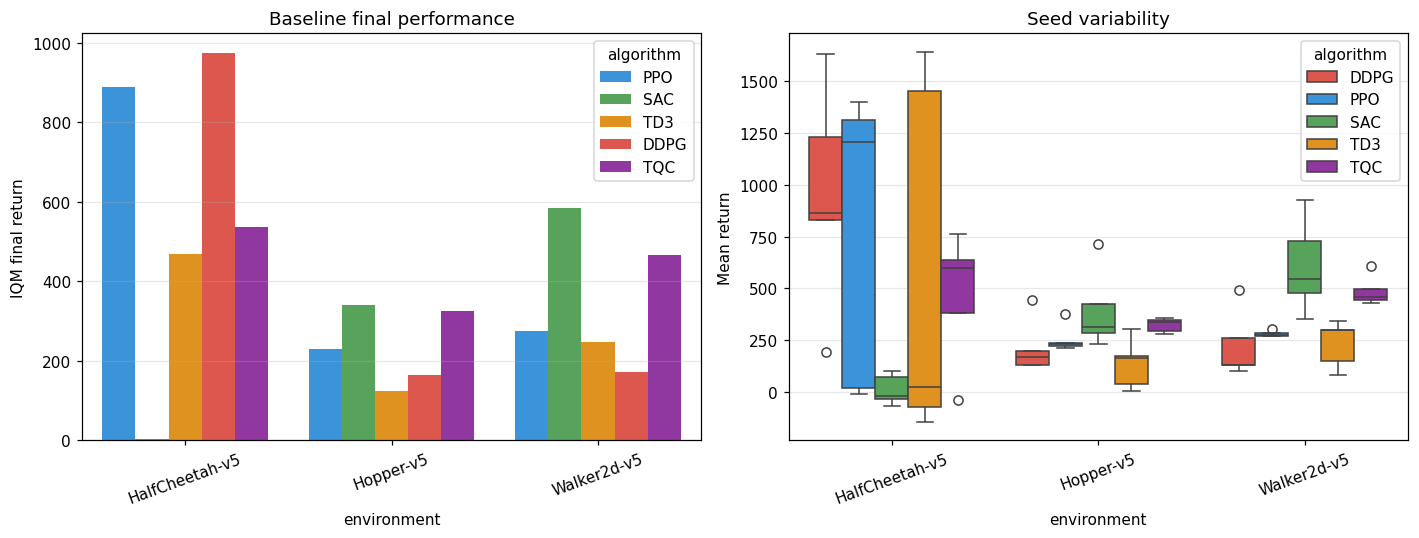

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if not perf_df.empty:
    sns.barplot(data=perf_df, x="environment", y="iqm_final_return", hue="algorithm", ax=axes[0], palette=COLORS)
    axes[0].set_title("Baseline final performance")
    axes[0].set_ylabel("IQM final return")
    axes[0].tick_params(axis="x", rotation=20)
if not final_eval.empty:
    sns.boxplot(data=final_eval, x="environment", y="mean_return", hue="algorithm", ax=axes[1], palette=COLORS)
    axes[1].set_title("Seed variability")
    axes[1].set_ylabel("Mean return")
    axes[1].tick_params(axis="x", rotation=20)
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_fig(fig, "fig_baseline_performance_variability")
plt.show()


## Robustness and ranking heatmap


Generated fig_baseline_robustness_ranking; existing figure files were left unchanged.


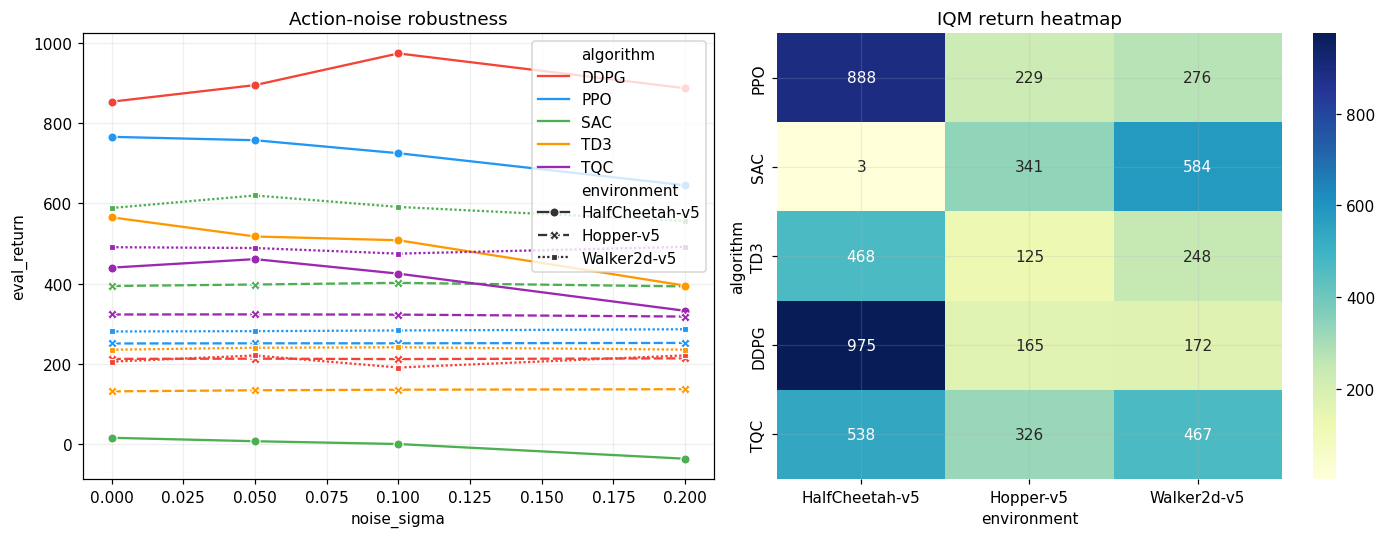

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if not robust_eval.empty:
    robust_summary = robust_eval.groupby(["environment", "algorithm", "noise_sigma"])["eval_return"].mean().reset_index()
    sns.lineplot(data=robust_summary, x="noise_sigma", y="eval_return", hue="algorithm",
                 style="environment", markers=True, ax=axes[0], palette=COLORS)
    axes[0].set_title("Action-noise robustness")
if not perf_df.empty:
    pivot = perf_df.pivot_table(index="algorithm", columns="environment", values="iqm_final_return")
    pivot = pivot.reindex(index=[a for a in ALGORITHMS if a in pivot.index], columns=ENV_IDS)
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1])
    axes[1].set_title("IQM return heatmap")
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
save_fig(fig, "fig_baseline_robustness_ranking")
plt.show()
